# Supply Chain & Inventory Analysis

**Dataset**: [DataCo Smart Supply Chain](https://www.kaggle.com/datasets/shashwatwork/dataco-smart-supply-chain-for-big-data-analysis) (Kaggle)
**Difficulty**: Intermediate | **Est. time**: 3-4 weeks

Third project in the [data-analysts-projects-101](../README.md) series, and the first one focused
on operations rather than a purely customer-facing product. Most DA portfolios only cover
digital/SaaS/retail-front-end datasets — this one is deliberately different: delivery performance,
reorder risk, and RFM analysis over 180,519 real orders.

**Architecture note**: as with every project in this repo, the analysis lives in
[`queries.sql`](./queries.sql), [`db.py`](./db.py) loads the data and runs it, and this notebook
+ `app.py` both call the same named queries.

Run `python download_data.py` once first to pull the dataset into `data/`.

**A data-handling note before we start**: this dataset ships fabricated-but-PII-shaped customer
fields (email, name, password, street address). `db.py` excludes them at load time — worth doing
as a habit even on a synthetic teaching dataset.


In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import db

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

con = db.get_connection()


## 1. Dataset overview

180,519 orders, 53 columns (44 after dropping the PII-shaped ones) spanning 5 fulfillment markets
and dozens of countries. Two columns anchor the delivery-performance analysis:
`Days for shipping (real)` vs. `Days for shipment (scheduled)`, plus a pre-computed
`Late_delivery_risk` flag (1 = delivered late).


In [2]:
orders = con.execute("SELECT * FROM orders").df()
print(f"{len(orders):,} orders, {orders.shape[1]} columns")
print(f"Late-delivery rate overall: {orders['Late_delivery_risk'].mean():.1%}")
orders["Shipping Mode"].value_counts()


180,519 orders, 44 columns
Late-delivery rate overall: 54.8%


Shipping Mode
Standard Class    107752
Second Class       35216
First Class        27814
Same Day            9737
Name: count, dtype: int64

## 2. Delivery performance by shipping mode

The obvious hypothesis: faster/premium shipping modes should have lower late-delivery rates. Let's
check with SQL directly (the doc's suggested query pattern) rather than assume.


,shipping_mode,total_orders,late_orders,late_pct,avg_delay_days
0,First Class,27814,26513.0,95.3,1.00
1,Second Class,35216,26987.0,76.6,1.99
2,Same Day,9737,4454.0,45.7,0.48
3,Standard Class,107752,41023.0,38.1,-0.00


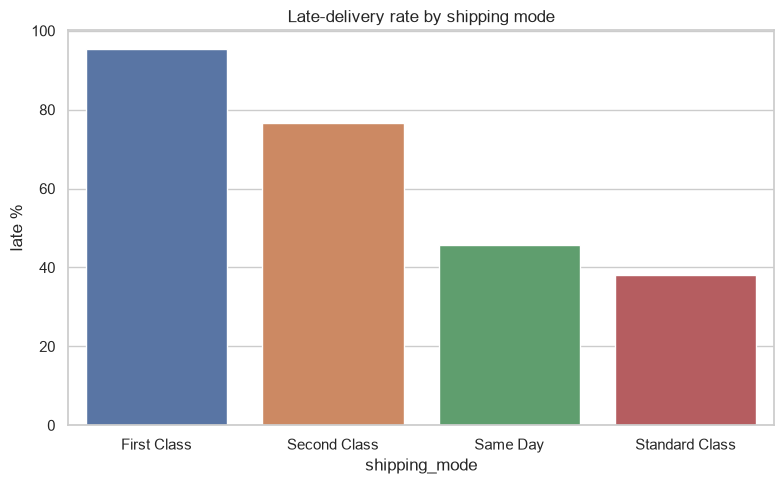

In [3]:
mode_df = db.run_query("late_shipment_by_mode", con)
display(mode_df)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(mode_df, x="shipping_mode", y="late_pct", hue="shipping_mode", legend=False, ax=ax)
ax.set_title("Late-delivery rate by shipping mode")
ax.set_ylabel("late %")
plt.tight_layout()
plt.show()


**Finding — and it's counterintuitive**: "First Class" has the *highest* late-delivery rate
(95.3%), not the lowest. "Same Day" is the most reliable (45.7% late). This is a real pattern in
this well-known dataset: the shipping mode labels appear to describe a *service tier a customer
paid for*, not the carrier's actual on-time performance — First Class orders are scheduled with
very tight windows (short "Days for shipment (scheduled)") that the fulfillment network then
routinely misses. It's exactly the kind of finding that's only visible once you actually query the
data instead of assuming "premium = faster = more reliable."


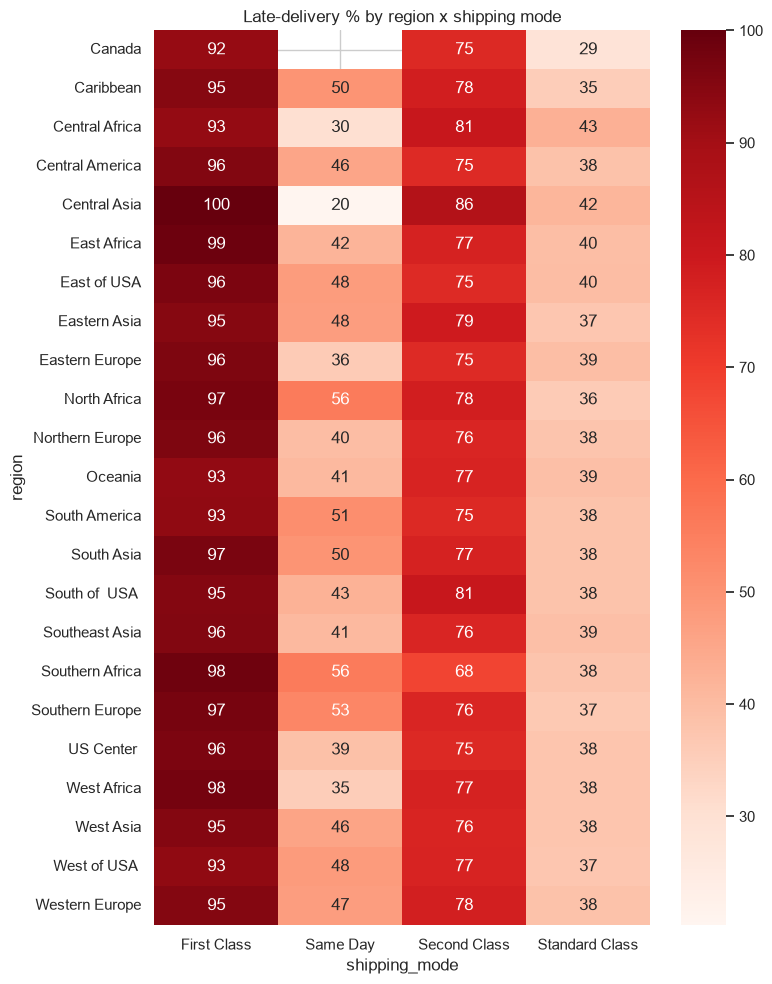

In [4]:
region_df = db.run_query("late_shipment_by_region", con)

heatmap_df = region_df.pivot(index="region", columns="shipping_mode", values="late_pct")
fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="Reds", ax=ax)
ax.set_title("Late-delivery % by region x shipping mode")
plt.tight_layout()
plt.show()


## 3. Reorder risk

The doc's sample query flags a SKU when `avg daily demand x lead time > current stock on hand`.
This dataset doesn't actually include a stock/inventory column, so a literal reorder-point alert
isn't computable here — worth stating plainly rather than fabricating a stock number. Instead, this
approximates *reorder risk* with a replenishment-burden score (`avg order quantity x avg lead time
in days`), and ranks products into risk quartiles with `NTILE(4)`. The top quartile is the set of
products that would need the tightest reorder-point monitoring in a system that did track stock.


In [5]:
risk_df = db.run_query("reorder_risk_by_product", con)
risk_df.head(10)


,product_name,category_name,order_count,avg_order_quantity,avg_lead_time_days,replenishment_burden,risk_quartile
0,Bridgestone e6 Straight Distance NFL Tennesse,Electronics,257,3.13,3.66,11.47,1
1,LIJA Women's Mid-Length Panel Golf Shorts,Golf Shoes,73,3.11,3.68,11.46,1
2,TaylorMade White Smoke IN-12 Putter,Women's Golf Clubs,63,3.06,3.73,11.43,1
3,Polar FT4 Heart Rate Monitor,Kids' Golf Clubs,60,3.27,3.48,11.38,1
4,Glove It Women's Mod Oval 3-Zip Carry All Gol,Trade-In,295,3.15,3.57,11.25,1
5,Merrell Women's Grassbow Sport Hiking Shoe,Men's Golf Clubs,70,2.96,3.79,11.19,1
6,Clicgear 8.0 Shoe Brush,Golf Gloves,285,3.12,3.58,11.14,1
7,Brooks Women's Ghost 6 Running Shoe,Boxing & MMA,66,3.21,3.45,11.10,1
8,Elevation Training Mask 2.0,Soccer,74,3.12,3.55,11.09,1
9,Titleist Pro V1x High Numbers Golf Balls,Electronics,265,3.02,3.66,11.05,1


## 4. Fulfillment market reliability

No distinct "supplier" field exists in this dataset, so `Market` (DataCo's own fulfillment-region
grouping: LATAM, Europe, Pacific Asia, USCA, Africa) stands in as the "supplier" entity for a
reliability-scoring exercise — on-time %, average profit ratio, and how many regions each market serves.


In [6]:
market_df = db.run_query("market_reliability", con)
market_df


,market,total_orders,on_time_pct,avg_profit_ratio,regions_served
0,LATAM,51594,45.6,0.121,3
1,Africa,11614,45.4,0.125,5
2,USCA,25799,45.2,0.122,5
3,Pacific Asia,41260,45.0,0.116,6
4,Europe,50252,44.8,0.122,4


## 5. RFM (Recency, Frequency, Monetary) customer segmentation

Classic customer-value segmentation: how recently did a customer order, how often, and how much did
they spend. Each dimension is scored into quartiles with `NTILE(4)` (4 = best), summed into an
overall RFM score, and bucketed into segments with a `CASE WHEN`.


In [7]:
rfm_df = db.run_query("rfm_analysis", con)
rfm_df.head(10)


,customer_id,recency_days,frequency,monetary,recency_score,frequency_score,monetary_score,rfm_score,segment
0,11645,145,13,6355.04,3,4,4,11,Champions
1,7954,142,9,6349.25,3,4,4,11,Champions
2,9371,147,11,8222.67,3,4,4,11,Champions
3,5654,122,15,7918.75,3,4,4,11,Champions
4,5624,129,12,7805.57,3,4,4,11,Champions
5,482,130,11,5968.39,3,4,4,11,Champions
6,1464,141,12,7546.26,3,4,4,11,Champions
7,5927,130,8,7545.55,3,4,4,11,Champions
8,3708,151,12,7455.45,3,4,4,11,Champions
9,1443,136,13,7410.93,3,4,4,11,Champions


,segment,customer_count,total_revenue,avg_revenue_per_customer
0,Loyal,10876,16512431.56,1518.24
1,Champions,3588,13541987.26,3774.24
2,At Risk,6087,2984743.18,490.35
3,Lost,101,15240.04,150.89


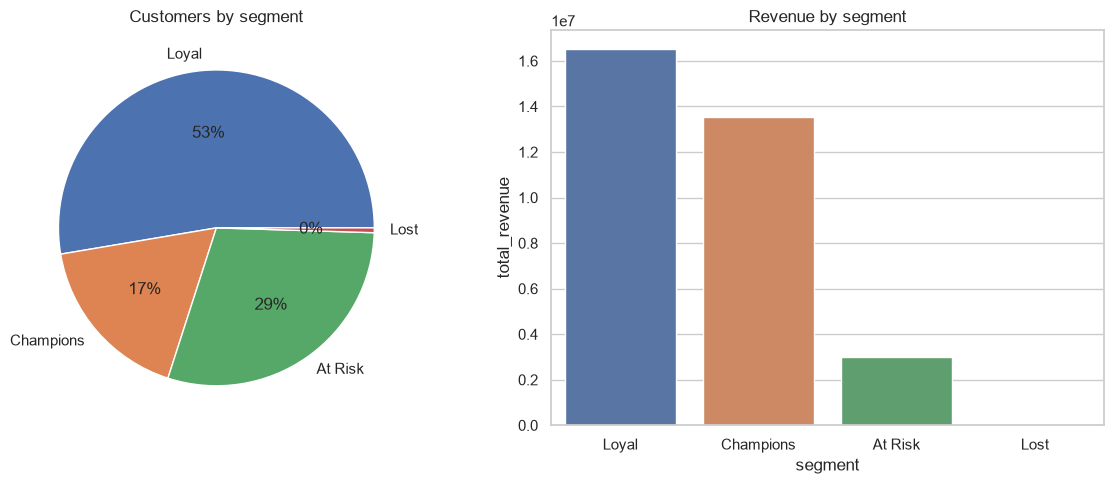

In [8]:
summary_df = db.run_query("rfm_segment_summary", con)
display(summary_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].pie(summary_df["customer_count"], labels=summary_df["segment"], autopct="%1.0f%%")
axes[0].set_title("Customers by segment")
sns.barplot(summary_df, x="segment", y="total_revenue", hue="segment", legend=False, ax=axes[1])
axes[1].set_title("Revenue by segment")
plt.tight_layout()
plt.show()


**Finding**: "Loyal" customers (high frequency/monetary but not the most recent) hold the largest
revenue share, followed closely by "Champions". "At Risk" customers still represent meaningful
historical spend — a retention campaign targeted at that segment specifically would likely have a
better ROI than a blanket win-back campaign across the full base.

## Key takeaways

- Shipping-mode label ≠ delivery reliability: "First Class" is the *least* reliable mode in this
  data (95.3% late), the opposite of what the name implies — always verify labels against actual
  outcomes before trusting them.
- Reorder risk had to be approximated (replenishment burden) rather than computed exactly, because
  the dataset lacks a stock/inventory column — a real-world reminder that "the query the business
  wants" and "the query the data supports" aren't always the same thing.
- RFM segmentation identifies that "Loyal" + "Champions" customers, while a minority by count, hold
  the majority of revenue — a concrete prioritization signal for a retention team.

## Next steps
```bash
streamlit run app.py
```
